In [7]:
import polars as pl
import matplotlib.pyplot as plt

In [8]:
world_bank_data = pl.read_csv("./Processed/world_bank_market_cap_weights.csv")
gfd_data = pl.read_csv("./Processed/gfd_market_cap_weights.csv")

# Coalesce the two datasets into a single DataFrame for export
combined_data = world_bank_data.join(gfd_data, on=["Year", "Country"], how="outer", suffix=" GFD").sort("Year")

coalesced_weights = (combined_data
    .select(
        pl.coalesce(pl.col("Country"), pl.col("Country GFD")).alias("Country"),
        pl.coalesce(pl.col("Year"), pl.col("Year GFD")).alias("Year"),
        pl.coalesce(pl.col("Percentage"), pl.col("Percentage GFD")).alias("Percentage"),
    )
)


C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_9268\2345684273.py:5: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  combined_data = world_bank_data.join(gfd_data, on=["Year", "Country"], how="outer", suffix=" GFD").sort("Year")


C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_9268\1127123613.py:19: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="Year", columns="Country", values="Percentage")
C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_9268\1127123613.py:26: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="Year", columns="Country", values="Percentage")
C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_9268\1127123613.py:33: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="Year", columns="Country", values="Percentage")


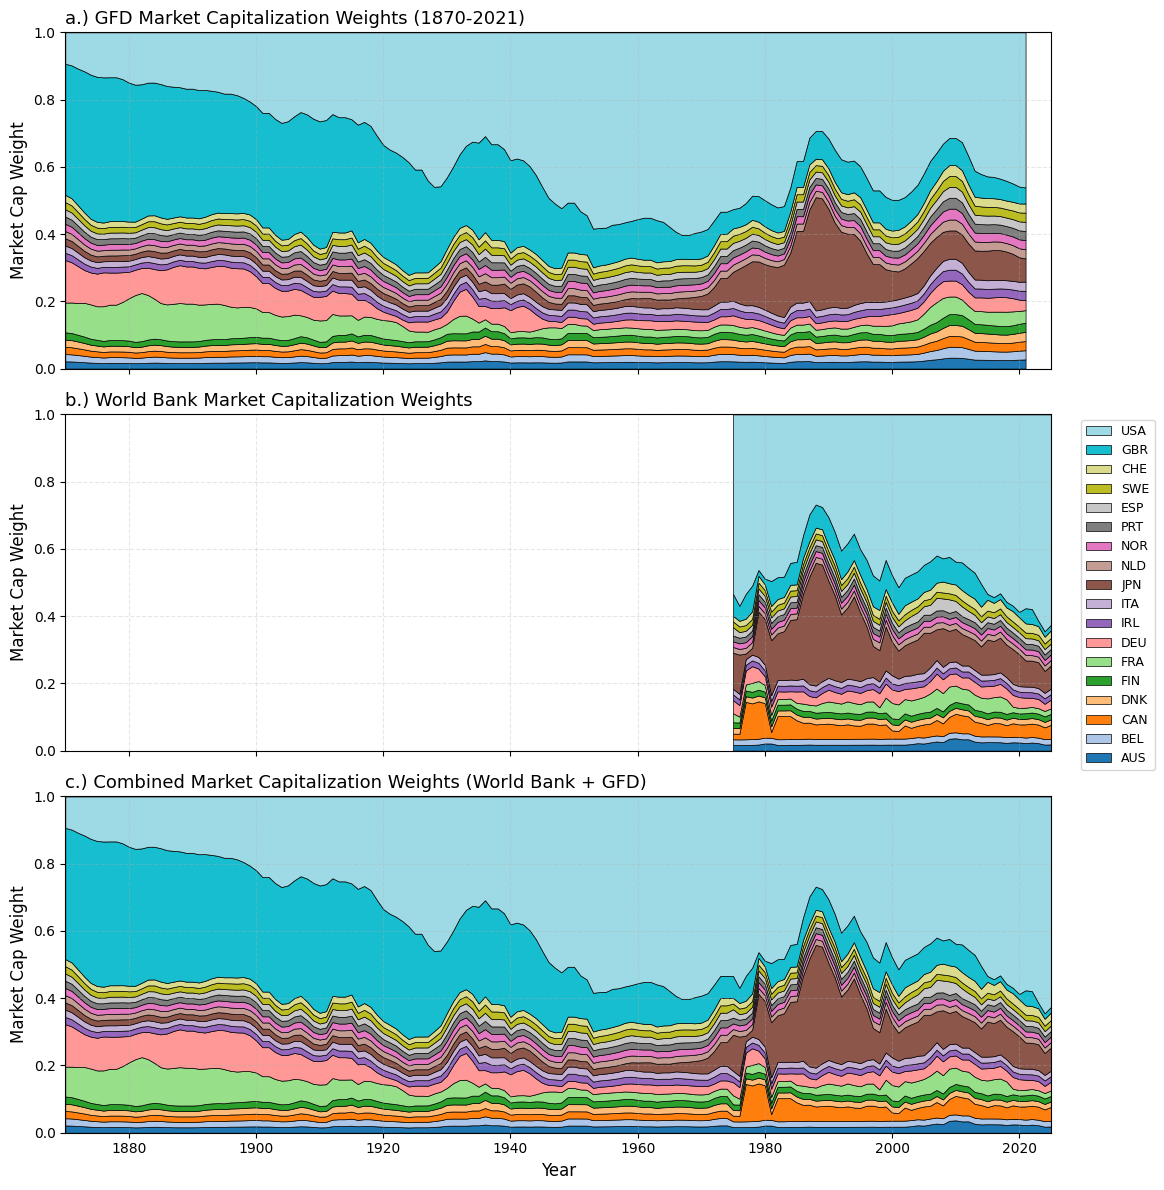

In [9]:
# Define JST countries for consistent ordering
JST_countries = [
    "AUS", "BEL", "CAN", "DNK", "FIN", "FRA", "DEU", "IRL", "ITA",
    "JPN", "NLD", "NOR", "PRT", "ESP", "SWE", "CHE", "GBR", "USA",
]

# Define consistent colors for each country
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Create a color palette using tab20 colormap
colors_map = plt.cm.tab20(np.linspace(0, 1, len(JST_countries)))
country_colors = {country: colors_map[i] for i, country in enumerate(JST_countries)}

# Pivot all three datasets to wide format
gfd_pivoted = (
    gfd_data
    .pivot(index="Year", columns="Country", values="Percentage")
    .sort("Year")
    .fill_null(0)
)

world_bank_pivoted = (
    world_bank_data
    .pivot(index="Year", columns="Country", values="Percentage")
    .sort("Year")
    .fill_null(0)
)

coalesced_pivoted = (
    coalesced_weights
    .pivot(index="Year", columns="Country", values="Percentage")
    .sort("Year")
    .fill_null(0)
)

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: GFD data (1870-2021)
gfd_polys = ax1.stackplot(
    gfd_pivoted["Year"],
    [gfd_pivoted[country] for country in JST_countries],
    colors=[country_colors[country] for country in JST_countries],
    labels=JST_countries,
    edgecolor='black',
    linewidth=0.5
)

ax1.set_ylabel("Market Cap Weight", fontsize=12)
ax1.set_title("a.) GFD Market Capitalization Weights (1870-2021)", fontsize=13, loc='left')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim(0, 1)

# Plot 2: World Bank data (1990+)
wb_polys = ax2.stackplot(
    world_bank_pivoted["Year"],
    [world_bank_pivoted[country] for country in JST_countries],
    colors=[country_colors[country] for country in JST_countries],
    labels=JST_countries,
    edgecolor='black',
    linewidth=0.5
)

ax2.set_ylabel("Market Cap Weight", fontsize=12)
ax2.set_title("b.) World Bank Market Capitalization Weights", fontsize=13, loc='left')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(0, 1)

# Plot 3: Coalesced data (World Bank where available, otherwise GFD)
coalesced_polys = ax3.stackplot(
    coalesced_pivoted["Year"],
    [coalesced_pivoted[country] for country in JST_countries],
    colors=[country_colors[country] for country in JST_countries],
    labels=JST_countries,
    edgecolor='black',
    linewidth=0.5
)

ax3.set_xlabel("Year", fontsize=12)
ax3.set_ylabel("Market Cap Weight", fontsize=12)
ax3.set_title("c.) Combined Market Capitalization Weights (World Bank + GFD)", fontsize=13, loc='left')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_ylim(0, 1)

# Set same x-axis limits for all plots (full range from GFD data)
x_min = gfd_pivoted["Year"].min()
x_max = max(gfd_pivoted["Year"].max(), world_bank_pivoted["Year"].max(), coalesced_pivoted["Year"].max())
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)
ax3.set_xlim(x_min, x_max)

# Create a single shared legend positioned to the right of the plots
handles, labels = ax1.get_legend_handles_labels()
handles, labels = handles[::-1], labels[::-1]  # Reverse the order
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.9, 0.5), fontsize=9, ncol=1)

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # Make room for the legend
plt.savefig("../../../Figs/combined_market_cap_weights.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print("=== Coalesced Data Quality Checks ===\n")

# Check 1: Verify percentages sum to approximately 1.0 for each year
yearly_sums = (
    coalesced_weights
    .group_by("Year")
    .agg(pl.col("Percentage").sum().alias("Total"))
)

print("1. Yearly percentage sums:")
print(f"   Min sum: {yearly_sums['Total'].min():.6f}")
print(f"   Max sum: {yearly_sums['Total'].max():.6f}")
print(f"   Mean sum: {yearly_sums['Total'].mean():.6f}")

# Check if any year deviates significantly from 1.0
problematic_years = yearly_sums.filter((pl.col("Total") < 0.98) | (pl.col("Total") > 1.02))
if len(problematic_years) > 0:
    print(f"   WARNING: {len(problematic_years)} years with totals outside [0.98, 1.02]")
    print(problematic_years)
else:
    print("   [OK] All years sum to approximately 1.0")

# Check 2: Verify no negative values
negative_count = coalesced_weights.filter(pl.col("Percentage") < 0).height
print(f"\n2. Negative values: {negative_count}")
if negative_count > 0:
    print("   WARNING: Found negative percentages!")
else:
    print("   [OK] No negative values")

# Check 3: Verify year coverage
year_range = coalesced_weights["Year"].unique().sort()
print(f"\n3. Year coverage: {year_range.min()} to {year_range.max()} ({len(year_range)} years)")
expected_years = year_range.max() - year_range.min() + 1
if len(year_range) == expected_years:
    print(f"   [OK] Complete coverage (no gaps)")
else:
    print(f"   WARNING: Expected {expected_years} years, found {len(year_range)} (possible gaps)")

# Check 4: Verify all countries present
countries_present = coalesced_weights["Country"].unique().sort()
print(f"\n4. Countries present: {len(countries_present)}")
print(f"   Expected: {len(JST_countries)}")
if len(countries_present) == len(JST_countries):
    print("   [OK] All countries present")
else:
    missing = set(JST_countries) - set(countries_present.to_list())
    extra = set(countries_present.to_list()) - set(JST_countries)
    if missing:
        print(f"   WARNING: Missing countries: {missing}")
    if extra:
        print(f"   WARNING: Extra countries: {extra}")

# Check 5: Verify data completeness per country-year
total_expected_rows = len(JST_countries) * len(year_range)
actual_rows = len(coalesced_weights)
print(f"\n5. Data completeness:")
print(f"   Expected rows: {total_expected_rows}")
print(f"   Actual rows: {actual_rows}")
if actual_rows == total_expected_rows:
    print("   [OK] All country-year combinations present")
else:
    print(f"   WARNING: Missing {total_expected_rows - actual_rows} country-year combinations")

# Check 6: Summary statistics by country
print(f"\n6. Summary statistics by country:")
print(coalesced_weights.group_by("Country").agg([
    pl.col("Percentage").mean().alias("Mean"),
    pl.col("Percentage").min().alias("Min"),
    pl.col("Percentage").max().alias("Max"),
    pl.col("Percentage").count().alias("Years"),
]).sort("Mean", descending=True))

# Write the coalesced weights to CSV
print("\n" + "="*50)
coalesced_weights.write_csv("./Final/coalesced_market_cap_weights.csv")
print("[OK] Data written to ./Final/coalesced_market_cap_weights.csv")

=== Coalesced Data Quality Checks ===

1. Yearly percentage sums:
   Min sum: 1.000000
   Max sum: 1.000000
   Mean sum: 1.000000
   [OK] All years sum to approximately 1.0

2. Negative values: 0
   [OK] No negative values

3. Year coverage: 1870 to 2025 (156 years)
   [OK] Complete coverage (no gaps)

4. Countries present: 18
   Expected: 18
   [OK] All countries present

5. Data completeness:
   Expected rows: 2808
   Actual rows: 2808
   [OK] All country-year combinations present

6. Summary statistics by country:
shape: (18, 5)
┌─────────┬──────────┬──────────┬──────────┬───────┐
│ Country ┆ Mean     ┆ Min      ┆ Max      ┆ Years │
│ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---   │
│ str     ┆ f64      ┆ f64      ┆ f64      ┆ u32   │
╞═════════╪══════════╪══════════╪══════════╪═══════╡
│ USA     ┆ 0.382876 ┆ 0.093375 ┆ 0.644851 ┆ 156   │
│ GBR     ┆ 0.206787 ┆ 0.016255 ┆ 0.431781 ┆ 156   │
│ JPN     ┆ 0.059218 ┆ 0.015689 ┆ 0.365317 ┆ 156   │
│ DEU     ┆ 0.05112  ┆ 0.017984 ┆ 0.12